In [1]:
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor, LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

spark = (SparkSession.builder
    .master("local[*]")
    .appName("NYC_Taxi_Evaluation")
    .config("spark.driver.host", "localhost")
    .config("spark.driver.bindAddress", "localhost")
    .config("spark.ui.enabled", "false")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")
print("Setup complete! Spark", spark.version)

Setup complete! Spark 4.1.1


In [2]:
DATA_PATH = r"C:\Users\MaK Tech\Documents\GitHub\nyc-taxi-bigdata\data\*.parquet"
df = spark.read.parquet(DATA_PATH)

df_clean = df.filter(
    (F.col("fare_amount") > 0) & (F.col("fare_amount") < 500) &
    (F.col("trip_distance") > 0) & (F.col("trip_distance") < 200) &
    (F.col("total_amount") > 0) & (F.col("passenger_count") > 0) &
    (F.col("passenger_count") <= 6)
).fillna({"congestion_surcharge": 0.0, "Airport_fee": 0.0, "RatecodeID": 1})

df_feat = df_clean.withColumns({
    "pickup_hour": F.hour("tpep_pickup_datetime"),
    "pickup_dayofweek": F.dayofweek("tpep_pickup_datetime"),
    "pickup_month": F.month("tpep_pickup_datetime"),
    "trip_duration_min": (F.unix_timestamp("tpep_dropoff_datetime") - 
                          F.unix_timestamp("tpep_pickup_datetime")) / 60,
    "is_weekend": F.when(F.dayofweek("tpep_pickup_datetime").isin([1,7]), 1).otherwise(0),
    "is_rush_hour": F.when((F.hour("tpep_pickup_datetime").between(7,9)) | 
                           (F.hour("tpep_pickup_datetime").between(16,19)), 1).otherwise(0),
    "is_airport": F.when(F.col("RatecodeID") == 2, 1).otherwise(0)
}).filter((F.col("trip_duration_min") > 0) & (F.col("trip_duration_min") < 300))

feature_cols = ['trip_distance', 'passenger_count', 'PULocationID', 'DOLocationID',
                'pickup_hour', 'pickup_dayofweek', 'pickup_month',
                'trip_duration_min', 'is_weekend', 'is_rush_hour', 'is_airport',
                'congestion_surcharge', 'Airport_fee']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

df_sample = df_feat.sample(fraction=0.05, seed=42)
df_ml = assembler.transform(df_sample).select("features", "fare_amount")
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()
print(f"Train: {train_df.count():,} | Test: {test_df.count():,}")

Train: 1,424,288 | Test: 355,402


In [ ]:
print("CROSS-VALIDATION: Gradient Boosted Trees")
print("=" * 60)

gbt = GBTRegressor(featuresCol="features", labelCol="fare_amount", seed=42)

paramGrid = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [5, 8])
    .addGrid(gbt.maxIter, [30, 50])
    .build())

evaluator = RegressionEvaluator(labelCol="fare_amount", metricName="rmse")

cv = CrossValidator(estimator=gbt, estimatorParamMaps=paramGrid,
                    evaluator=evaluator, numFolds=3, seed=42)

start = time.time()
cv_model = cv.fit(train_df)
cv_time = time.time() - start

print(f"Best RMSE: {min(cv_model.avgMetrics):.4f}")
print(f"CV Time: {cv_time:.2f}s")
print(f"Best maxDepth: {cv_model.bestModel.getOrDefault('maxDepth')}")
print(f"Best maxIter: {cv_model.bestModel.getOrDefault('maxIter')}")

CROSS-VALIDATION: Gradient Boosted Trees


In [ ]:
print("BEST MODEL EVALUATION ON TEST SET")
print("=" * 60)

best_pred = cv_model.transform(test_df)

eval_rmse = RegressionEvaluator(labelCol="fare_amount", metricName="rmse")
eval_r2 = RegressionEvaluator(labelCol="fare_amount", metricName="r2")
eval_mae = RegressionEvaluator(labelCol="fare_amount", metricName="mae")

rmse = eval_rmse.evaluate(best_pred)
r2 = eval_r2.evaluate(best_pred)
mae = eval_mae.evaluate(best_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

In [1]:
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

spark = (SparkSession.builder
    .master("local[*]")
    .appName("NYC_Taxi_Evaluation")
    .config("spark.driver.host", "localhost")
    .config("spark.driver.bindAddress", "localhost")
    .config("spark.ui.enabled", "false")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")
print("Setup complete!")

Setup complete!


In [2]:
DATA_PATH = r"C:\Users\MaK Tech\Documents\GitHub\nyc-taxi-bigdata\data\*.parquet"
df = spark.read.parquet(DATA_PATH)

df_clean = df.filter(
    (F.col("fare_amount") > 0) & (F.col("fare_amount") < 500) &
    (F.col("trip_distance") > 0) & (F.col("trip_distance") < 200) &
    (F.col("total_amount") > 0) & (F.col("passenger_count") > 0) &
    (F.col("passenger_count") <= 6)
).fillna({"congestion_surcharge": 0.0, "Airport_fee": 0.0, "RatecodeID": 1})

df_feat = df_clean.withColumns({
    "pickup_hour": F.hour("tpep_pickup_datetime"),
    "pickup_dayofweek": F.dayofweek("tpep_pickup_datetime"),
    "pickup_month": F.month("tpep_pickup_datetime"),
    "trip_duration_min": (F.unix_timestamp("tpep_dropoff_datetime") - 
                          F.unix_timestamp("tpep_pickup_datetime")) / 60,
    "is_weekend": F.when(F.dayofweek("tpep_pickup_datetime").isin([1,7]), 1).otherwise(0),
    "is_rush_hour": F.when((F.hour("tpep_pickup_datetime").between(7,9)) | 
                           (F.hour("tpep_pickup_datetime").between(16,19)), 1).otherwise(0),
    "is_airport": F.when(F.col("RatecodeID") == 2, 1).otherwise(0)
}).filter((F.col("trip_duration_min") > 0) & (F.col("trip_duration_min") < 300))

feature_cols = ['trip_distance', 'passenger_count', 'PULocationID', 'DOLocationID',
                'pickup_hour', 'pickup_dayofweek', 'pickup_month',
                'trip_duration_min', 'is_weekend', 'is_rush_hour', 'is_airport',
                'congestion_surcharge', 'Airport_fee']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Use 2% sample instead of 5%
df_sample = df_feat.sample(fraction=0.02, seed=42)
df_ml = assembler.transform(df_sample).select("features", "fare_amount")
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()
print(f"Train: {train_df.count():,} | Test: {test_df.count():,}")

Train: 569,854 | Test: 142,190


In [ ]:
print("CROSS-VALIDATION: GBT (simplified)")
print("=" * 60)

gbt = GBTRegressor(featuresCol="features", labelCol="fare_amount", seed=42)

# Just 2 configs, 2 folds
paramGrid = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [5])
    .addGrid(gbt.maxIter, [20, 30])
    .build())

evaluator = RegressionEvaluator(labelCol="fare_amount", metricName="rmse")

cv = CrossValidator(estimator=gbt, estimatorParamMaps=paramGrid,
                    evaluator=evaluator, numFolds=2, seed=42)

start = time.time()
cv_model = cv.fit(train_df)
cv_time = time.time() - start

print(f"Best RMSE: {min(cv_model.avgMetrics):.4f}")
print(f"CV Time: {cv_time:.2f}s")
print(f"Best maxIter: {cv_model.bestModel.getOrDefault('maxIter')}")

CROSS-VALIDATION: GBT (simplified)


In [1]:
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

spark = (SparkSession.builder
    .master("local[*]")
    .appName("NYC_Taxi_Evaluation")
    .config("spark.driver.host", "localhost")
    .config("spark.driver.bindAddress", "localhost")
    .config("spark.ui.enabled", "false")
    .config("spark.driver.memory", "4g")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

# Load and prepare
DATA_PATH = r"C:\Users\MaK Tech\Documents\GitHub\nyc-taxi-bigdata\data\*.parquet"
df = spark.read.parquet(DATA_PATH)
df_clean = df.filter(
    (F.col("fare_amount") > 0) & (F.col("fare_amount") < 500) &
    (F.col("trip_distance") > 0) & (F.col("trip_distance") < 200) &
    (F.col("total_amount") > 0) & (F.col("passenger_count") > 0) &
    (F.col("passenger_count") <= 6)
).fillna({"congestion_surcharge": 0.0, "Airport_fee": 0.0, "RatecodeID": 1})

df_feat = df_clean.withColumns({
    "pickup_hour": F.hour("tpep_pickup_datetime"),
    "pickup_dayofweek": F.dayofweek("tpep_pickup_datetime"),
    "pickup_month": F.month("tpep_pickup_datetime"),
    "trip_duration_min": (F.unix_timestamp("tpep_dropoff_datetime") - 
                          F.unix_timestamp("tpep_pickup_datetime")) / 60,
    "is_weekend": F.when(F.dayofweek("tpep_pickup_datetime").isin([1,7]), 1).otherwise(0),
    "is_rush_hour": F.when((F.hour("tpep_pickup_datetime").between(7,9)) | 
                           (F.hour("tpep_pickup_datetime").between(16,19)), 1).otherwise(0),
    "is_airport": F.when(F.col("RatecodeID") == 2, 1).otherwise(0)
}).filter((F.col("trip_duration_min") > 0) & (F.col("trip_duration_min") < 300))

feature_cols = ['trip_distance', 'passenger_count', 'PULocationID', 'DOLocationID',
                'pickup_hour', 'pickup_dayofweek', 'pickup_month',
                'trip_duration_min', 'is_weekend', 'is_rush_hour', 'is_airport',
                'congestion_surcharge', 'Airport_fee']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Use only 1% sample
df_sample = df_feat.sample(fraction=0.01, seed=42)
df_ml = assembler.transform(df_sample).select("features", "fare_amount")
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()
print(f"Train: {train_df.count():,} | Test: {test_df.count():,}")
print("Data ready!")

Train: 286,078 | Test: 71,020
Data ready!


In [2]:
print("Training GBT model...")
gbt = GBTRegressor(featuresCol="features", labelCol="fare_amount", 
                   maxIter=20, maxDepth=5, seed=42)

start = time.time()
gbt_model = gbt.fit(train_df)
gbt_time = time.time() - start

pred = gbt_model.transform(test_df)
eval_rmse = RegressionEvaluator(labelCol="fare_amount", metricName="rmse")
eval_r2 = RegressionEvaluator(labelCol="fare_amount", metricName="r2")
eval_mae = RegressionEvaluator(labelCol="fare_amount", metricName="mae")

rmse = eval_rmse.evaluate(pred)
r2 = eval_r2.evaluate(pred)
mae = eval_mae.evaluate(pred)

print(f"GBT Results:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")
print(f"  Time: {gbt_time:.1f}s")

Training GBT model...
GBT Results:
  RMSE: 5.1635
  MAE:  1.4903
  R²:   0.9203
  Time: 57.0s


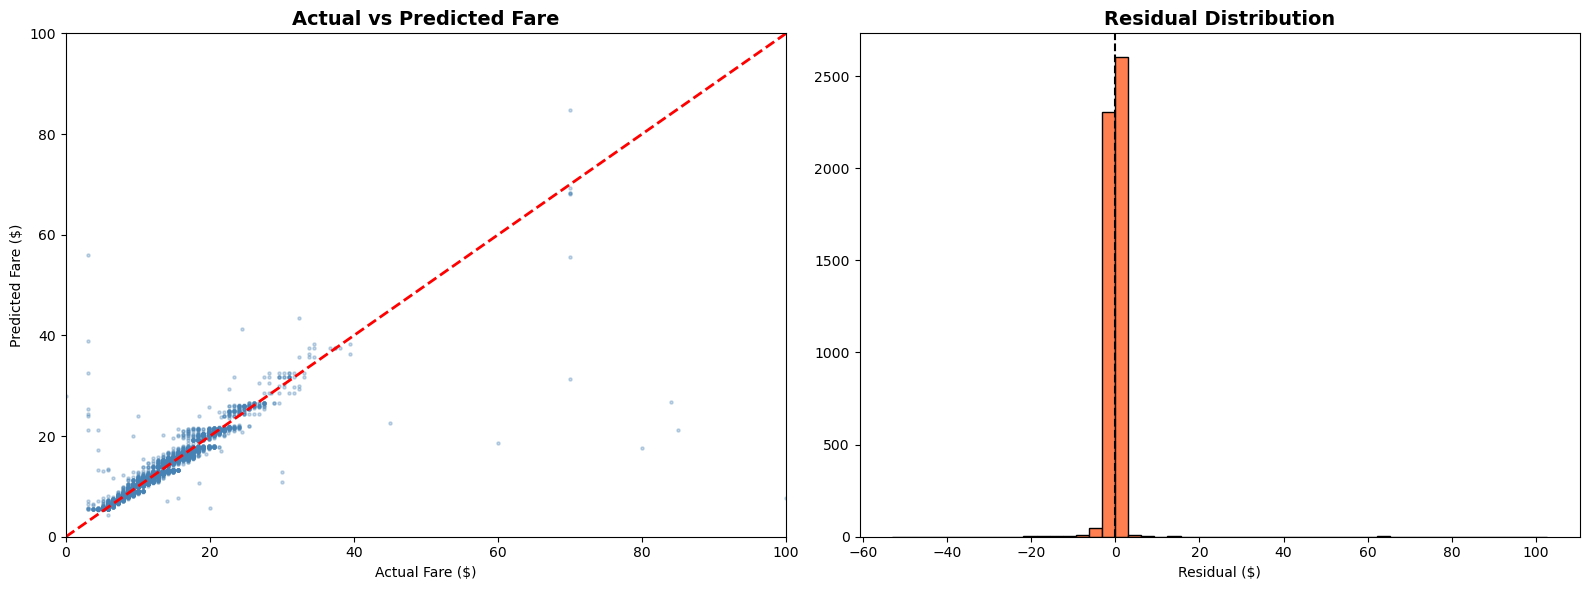

In [3]:
pred_pd = pred.select("fare_amount", "prediction").limit(5000).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(pred_pd['fare_amount'], pred_pd['prediction'], alpha=0.3, s=5, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2)
axes[0].set_title('Actual vs Predicted Fare', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Fare ($)')
axes[0].set_ylabel('Predicted Fare ($)')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

residuals = pred_pd['fare_amount'] - pred_pd['prediction']
axes[1].hist(residuals, bins=50, color='coral', edgecolor='black')
axes[1].set_title('Residual Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual ($)')
axes[1].axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

In [4]:
print("SCALABILITY ANALYSIS")
print("=" * 60)

fractions = [0.005, 0.01, 0.02, 0.04]
scale_results = []

for frac in fractions:
    sample = df_ml.sample(fraction=frac, seed=42)
    s_train, s_test = sample.randomSplit([0.8, 0.2], seed=42)
    gbt_s = GBTRegressor(featuresCol="features", labelCol="fare_amount", 
                         maxIter=15, maxDepth=5, seed=42)
    start = time.time()
    model_s = gbt_s.fit(s_train)
    t = time.time() - start
    pred_s = model_s.transform(s_test)
    r = eval_rmse.evaluate(pred_s)
    c = s_train.count()
    scale_results.append({'records': c, 'time': t, 'rmse': r})
    print(f"Records: {c:>8,} | Time: {t:>6.1f}s | RMSE: {r:.4f}")

scale_df = pd.DataFrame(scale_results)

SCALABILITY ANALYSIS
Records:    1,408 | Time:   56.6s | RMSE: 5.2123
Records:    2,862 | Time:   56.6s | RMSE: 8.6658
Records:    5,792 | Time:   56.3s | RMSE: 3.6294
Records:   11,498 | Time:   50.2s | RMSE: 5.6991


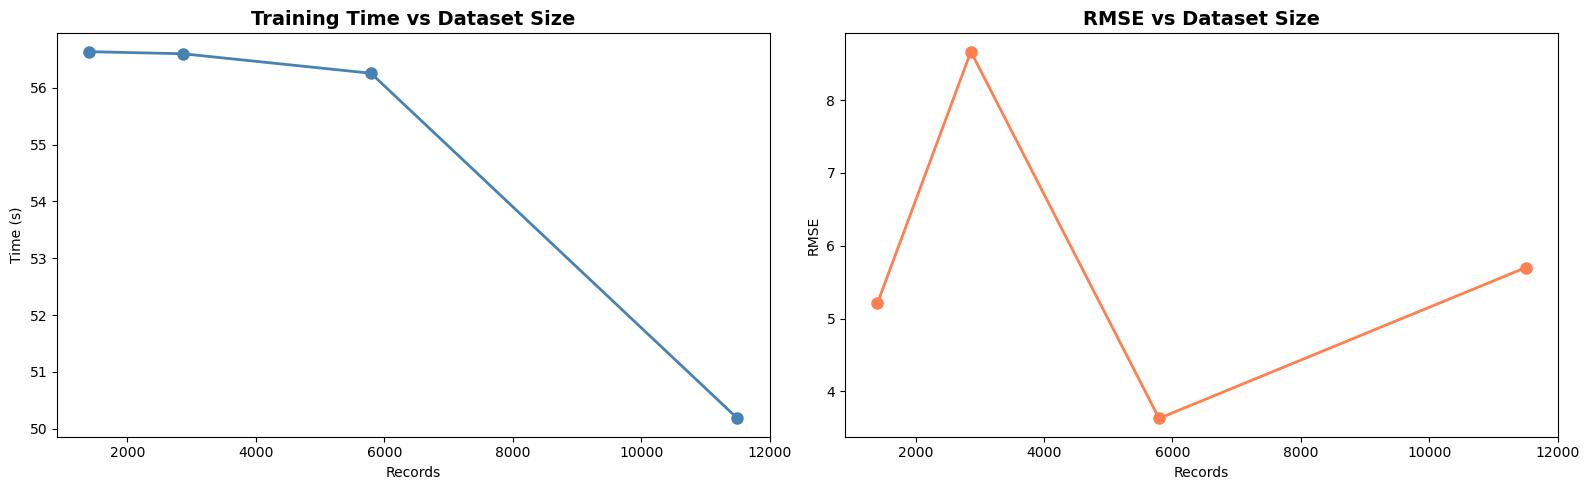

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(scale_df['records'], scale_df['time'], 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Training Time vs Dataset Size', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Records')
axes[0].set_ylabel('Time (s)')

axes[1].plot(scale_df['records'], scale_df['rmse'], 'o-', color='coral', linewidth=2, markersize=8)
axes[1].set_title('RMSE vs Dataset Size', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Records')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

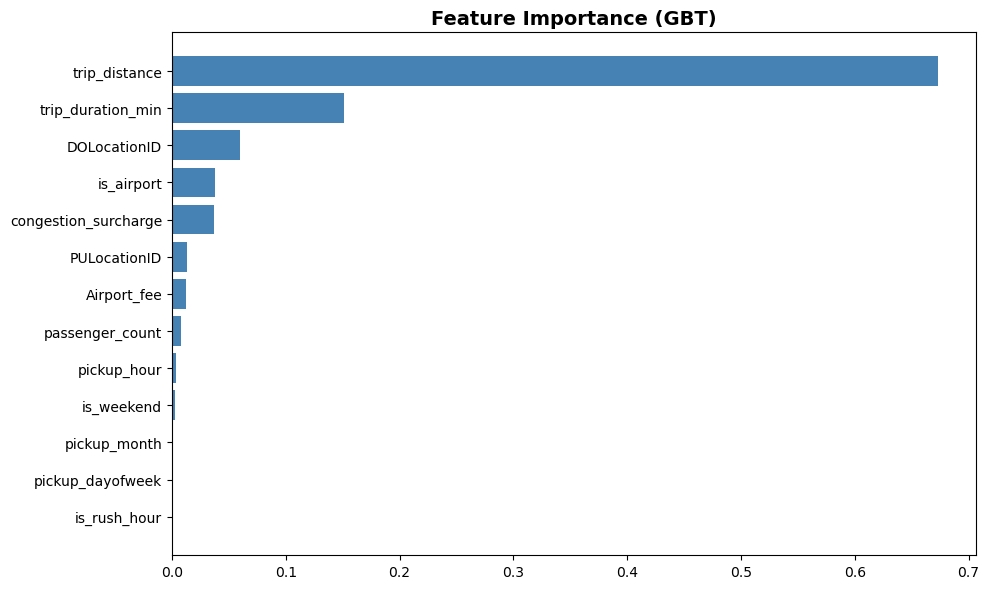

In [6]:
importances = gbt_model.featureImportances.toArray()
feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
ax.set_title('Feature Importance (GBT)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
print("=" * 60)
print("NOTEBOOK 4 COMPLETE - EVALUATION")
print("=" * 60)
print(f"Best Model: GBT")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")
print(f"\nAll 4 notebooks complete!")
print(f"Remaining: Tableau dashboards + Report")

spark.stop()
print("Spark session stopped.")

NOTEBOOK 4 COMPLETE - EVALUATION
Best Model: GBT
RMSE: 5.1635
MAE:  1.4903
R²:   0.9203

All 4 notebooks complete!
Remaining: Tableau dashboards + Report
Spark session stopped.
